Load dataset
Check shape
Check data types
Find missing values
Remove duplicates
Drop unnecessary columns
Fix incorrect values
Save cleaned data

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r'D:\Desktop\mlops\customer-churn-monitoring-mlops\data\raw\data.csv')
df.head(3)

,customer_id,tenure_months,monthly_charges,usage_minutes,support_calls,payment_delay_days,contract_type,autopay,num_services,satisfaction_score,signup_channel,marketing_segment,favorite_color,lucky_number,churn
0,CUST100000,60,78.04,512,8,4.4,two-year,1,3,6.0,referral,B,yellow,7,0
1,CUST100001,6,140.22,170,3,5.4,month-to-month,0,2,5.0,referral,B,red,18,0
2,CUST100002,39,89.22,377,1,0.0,month-to-month,0,2,10.0,ads,C,green,72,1


In [4]:
df.shape

(11000, 15)

In [9]:
df.isnull().sum()

customer_id           0
tenure_months         0
monthly_charges       0
usage_minutes         0
support_calls         0
payment_delay_days    0
contract_type         0
autopay               0
num_services          0
satisfaction_score    0
signup_channel        0
marketing_segment     0
favorite_color        0
lucky_number          0
churn                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.drop(columns = ['customer_id','favorite_color','lucky_number'])

,tenure_months,monthly_charges,usage_minutes,support_calls,payment_delay_days,contract_type,autopay,num_services,satisfaction_score,signup_channel,marketing_segment,churn
0,60,78.04,512,8,4.4,two-year,1,3,6.0,referral,B,0
1,6,140.22,170,3,5.4,month-to-month,0,2,5.0,referral,B,0
2,39,89.22,377,1,0.0,month-to-month,0,2,10.0,ads,C,1
3,54,40.36,401,0,0.9,two-year,0,5,10.0,organic,B,0
4,33,112.11,377,4,0.6,month-to-month,1,4,4.5,organic,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10995,20,62.29,595,2,0.0,month-to-month,1,3,9.2,organic,B,0
10996,45,144.31,514,1,6.1,one-year,1,5,5.5,referral,C,0
10997,63,88.40,620,0,0.7,two-year,0,4,6.8,organic,A,0
10998,44,143.62,336,0,0.7,one-year,1,1,5.3,partner,B,0


In [39]:
import matplotlib.pyplot as plt

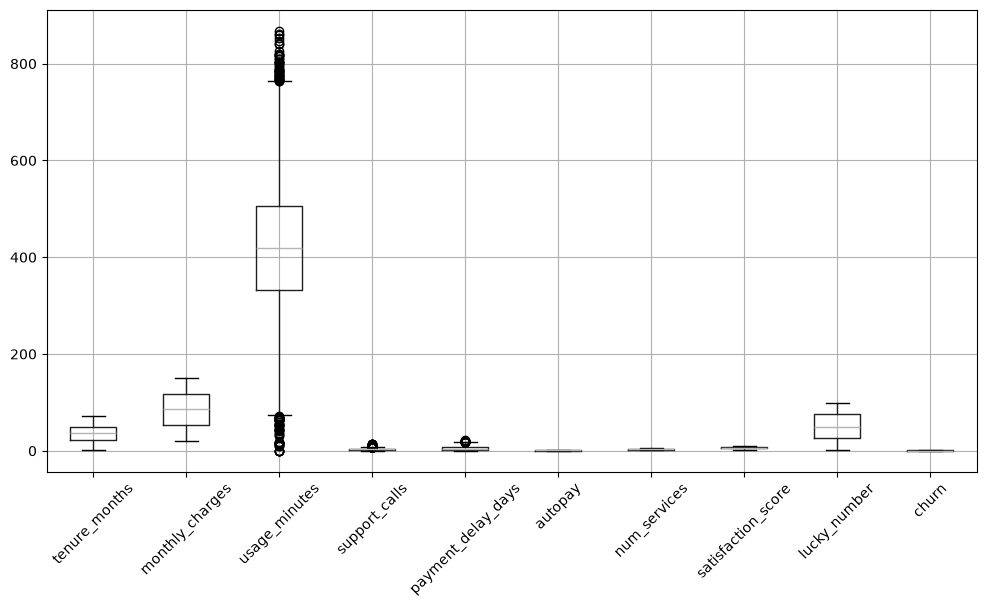

In [40]:
df.select_dtypes(include='number').boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

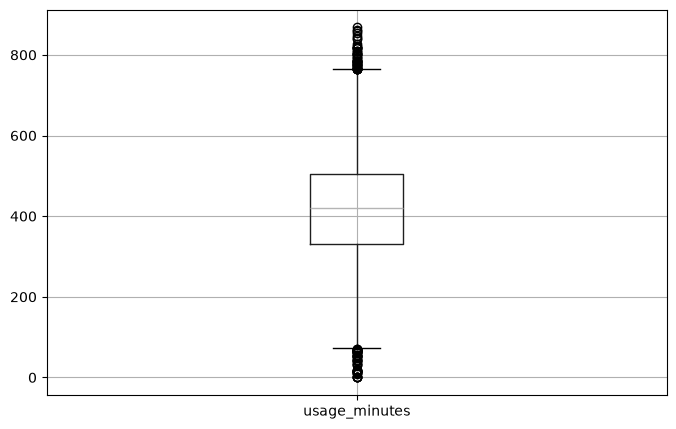

In [41]:
df.boxplot(column=['usage_minutes'], figsize=(8, 5))
plt.show()

In [42]:
Q1 = df['usage_minutes'].quantile(0.25)
Q3 = df['usage_minutes'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (df['usage_minutes'] < lower) | (df['usage_minutes'] > upper)

outlier_count = mask.sum()
total_count = len(df)
outlier_percentage = (outlier_count / total_count) * 100

print(outlier_percentage)

0.8999999999999999


In [43]:
df.select_dtypes(exclude='number').columns

Index(['customer_id', 'contract_type', 'signup_channel', 'marketing_segment',
       'favorite_color'],
      dtype='str')

In [36]:
df.select_dtypes(include='number').columns

Index(['tenure_months', 'monthly_charges', 'usage_minutes', 'support_calls',
       'payment_delay_days', 'autopay', 'num_services', 'satisfaction_score',
       'lucky_number', 'churn'],
      dtype='str')